In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

df = pd.read_csv('Names_dataset.csv')

print(df.columns)   
print("Shape before cleaning:", df.shape)
print(df.head())

Index(['name', 'gender'], dtype='object')
Shape before cleaning: (125231, 2)
      name gender
0   alfiya      f
1   ardwin      m
2  henryka      f
3   preeti      f
4   jamaro      m


In [20]:
print(df.columns.tolist())

['name', 'gender']


In [21]:
# --- Cleaning Dataset---
df.columns = df.columns.str.strip().str.lower()
df = df.drop_duplicates()
df = df.dropna(subset=['name', 'gender'])

df['name'] = df['name'].astype(str).str.strip().str.lower()
df['gender'] = df['gender'].astype(str).str.strip().str.lower()

df['gender'] = df['gender'].replace({'male': 'm', 'female': 'f'})
df = df[df['gender'].isin(['m', 'f'])]

In [22]:
# only alphabetic names, remove 1-letter junk
df = df[df['name'].str.match(r'^[a-z]+$')]
df = df[df['name'].str.len() >= 2]
df = df.reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print(df['gender'].value_counts())

Shape after cleaning: (98240, 2)
gender
f    62087
m    36153
Name: count, dtype: int64


In [23]:
def extract_features(name):
    return {
        'last_letter': name[-1],
        'last_two': name[-2:] if len(name) >= 2 else name,
        'first_letter': name[0],
        'length': len(name),
        'vowel_ratio': sum(ch in 'aeiou' for ch in name) / len(name)
    }

df_names = df['name'].tolist()
df_genders = df['gender'].tolist()

feature_dicts = [extract_features(n) for n in df_names]
y = np.array([1 if g == 'm' else 0 for g in df_genders]) 

In [24]:
#Build numeric vectors (for logistic Regression & KNN)

def build_vocab(values):
    unique_vals = sorted(set(values))
    return {v: i for i, v in enumerate(unique_vals)}

last_letter_vocab = build_vocab([f['last_letter'] for f in feature_dicts])
last_two_vocab   = build_vocab([f['last_two'] for f in feature_dicts])
first_letter_vocab = build_vocab([f['first_letter'] for f in feature_dicts])

def one_hot(value, vocab):
    vec = np.zeros(len(vocab))
    if value in vocab:
        vec[vocab[value]] = 1
    return vec

def build_feature_vector(f):
    return np.concatenate([
        one_hot(f['last_letter'], last_letter_vocab),
        one_hot(f['last_two'], last_two_vocab),
        one_hot(f['first_letter'], first_letter_vocab),
        np.array([f['length'], f['vowel_ratio']])
    ])

X = np.array([build_feature_vector(f) for f in feature_dicts])
print("Feature matrix shape:", X.shape)

Feature matrix shape: (98240, 504)


In [25]:
#train-test split
def train_test_split(n, test_size=0.2, seed=42):
    np.random.seed(seed)
    idx = np.random.permutation(n)
    test_count = int(n * test_size)
    return idx[test_count:], idx[:test_count]   

train_idx, test_idx = train_test_split(len(y))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

feat_train = [feature_dicts[i] for i in train_idx]
feat_test  = [feature_dicts[i] for i in test_idx]

print("Train size:", len(train_idx), "Test size:",len(test_idx))

Train size: 78592 Test size: 19648


In [26]:
numeric_cols = X_train[:, -2:]  
mean = numeric_cols.mean(axis=0)
std = numeric_cols.std(axis=0)

X_train[:, -2:] = (X_train[:, -2:] - mean) / std
X_test[:, -2:] = (X_test[:, -2:] - mean) / std   

In [27]:
#Model-01: Naive Bayes
class NaiveBayesClassifier:
    def __init__(self):
        self.feature_names = ['last_letter', 'last_two', 'first_letter']

    def fit(self, feature_dicts, labels):
        self.classes = sorted(set(labels))
        total_n = len(labels)
        counts = Counter(labels)
        self.priors = {c: counts[c] / total_n for c in self.classes}

        self.value_counts = {
            c: {f: Counter() for f in self.feature_names} for c in self.classes
        }
        for feats, label in zip(feature_dicts, labels):
            for f in self.feature_names:
                self.value_counts[label][f][feats[f]] += 1

        self.vocab_size = {
            f: len(set(feats[f] for feats in feature_dicts)) 
            for f in self.feature_names
        }

    def _likelihood(self, f, value, c):
        count = self.value_counts[c][f][value]
        total = sum(self.value_counts[c][f].values())
        return (count + 1) / (total + self.vocab_size[f])   # Laplace smoothing

    def predict_one(self, feats):
        scores = {}
        for c in self.classes:
            score = np.log(self.priors[c])
            for f in self.feature_names:
                score += np.log(self._likelihood(f, feats[f], c))
            scores[c] = score
        return max(scores, key=scores.get)

    def predict(self, feature_list):
        return [self.predict_one(f) for f in feature_list]

nb_model = NaiveBayesClassifier()
nb_model.fit(feat_train, y_train)
nb_preds = nb_model.predict(feat_test)

In [28]:
print("Dataset shape:", df.shape)
print("Feature matrix X shape:", X.shape)
print("X_train shape:", X_train.shape)

Dataset shape: (98240, 2)
Feature matrix X shape: (98240, 504)
X_train shape: (78592, 504)


In [29]:
#Model-02: Logistic Regression

class LogisticRegressionScratch:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.epochs):
            linear_output = np.dot(X,self.weights) + self.bias
            predictions = self.sigmoid(linear_output)
            
            error = predictions - y
            self.weights -= self.lr * np.dot(X.T, error) / n_samples
            self.bias -= self.lr * np.sum(error) / n_samples
            loss = -np.mean(y*np.log(predictions+1e-9) + (1-y)*np.log(1-predictions+1e-9))
            self.loss_history.append(loss)

    def predict(self, X, threshold=0.5):
        return (self.sigmoid(np.dot(X , self.weights) + self.bias) >= threshold).astype(int)

log_reg_model = LogisticRegressionScratch(lr =0.5, epochs=300)
log_reg_model.fit(X_train, y_train)
lr_preds_num = log_reg_model.predict(X_test)
lr_preds = lr_preds_num   


In [30]:
#Model-03: KNN
class KNNClassifier:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train= X
        self.y_train = y

    def predict(self, X_test, batch_size=200):
        preds= []
        for start in range(0, len(X_test), batch_size):
            batch = X_test[start:start + batch_size]
            dists = np.sum(batch**2, axis=1)[:, None] + \
                    np.sum(self.X_train**2, axis=1)[None, :] - \
                    2 * np.dot(batch, self.X_train.T)
            nearest_idx = np.argsort(dists, axis=1)[:, :self.k]
            nearest_labels = self.y_train[nearest_idx]
            batch_preds = [Counter(row).most_common(1)[0][0] for row in nearest_labels]
            preds.extend(batch_preds)
        return np.array(preds)

# KNN on large one-hot data is slow, so we train on a subsample
KNN_TRAIN_LIMIT = 3000
knn_train_idx = np.random.RandomState(42).choice(
    len(X_train), size=min(KNN_TRAIN_LIMIT, len(X_train)), replace=False
)

knn_model = KNNClassifier(k=7)
knn_model.fit(X_train[knn_train_idx], y_train[knn_train_idx])
knn_preds = knn_model.predict(X_test)


In [31]:
#Evaluation (accuracy, confusion matrix)

def accuracy_manual(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))

def confusion_matrix(y_true, y_pred):
    matrix = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        matrix[t][p] += 1
    return matrix

nb_acc = accuracy_manual(y_test, nb_preds)
lr_acc = accuracy_manual(y_test, lr_preds)
knn_acc = accuracy_manual(y_test, knn_preds)

print("--------Accuracy Results--------------")
print(f"Naive Bayes accuracy:          {nb_acc*100:.2f}%")
print(f"Logistic Regression accuracy:  {lr_acc*100:.2f}%")
print(f"KNN accuracy:                  {knn_acc*100:.2f}%")

--------Accuracy Results--------------
Naive Bayes accuracy:          82.28%
Logistic Regression accuracy:  81.29%
KNN accuracy:                  80.47%


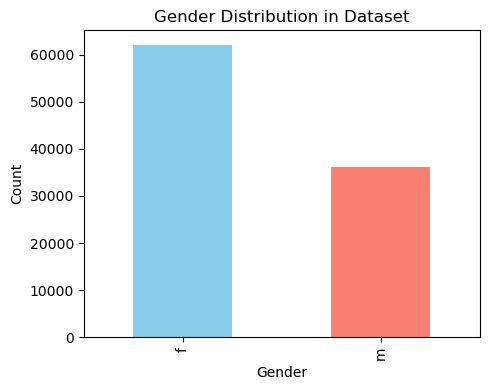

In [32]:
# Validation
#--- Gender distribution ---

plt.figure(figsize=(5,4))
df['gender'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title('Gender Distribution in Dataset')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

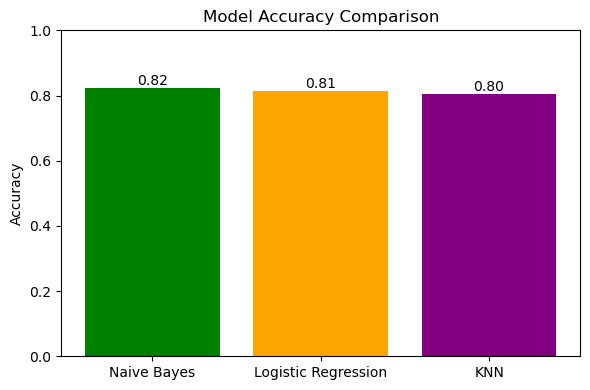

In [33]:
# --- Model accuracy comparison ---
models = ['Naive Bayes', 'Logistic Regression', 'KNN']
accs = [nb_acc, lr_acc, knn_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accs, color=['green','orange','purple'])
plt.ylim(0,1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(accs):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()

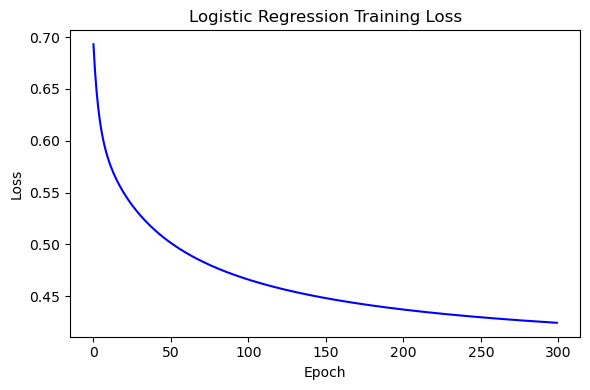

In [34]:
# --- Logistic Regression training loss curve ---
plt.figure(figsize=(6,4))
plt.plot(log_reg_model.loss_history, color='blue')
plt.title('Logistic Regression Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

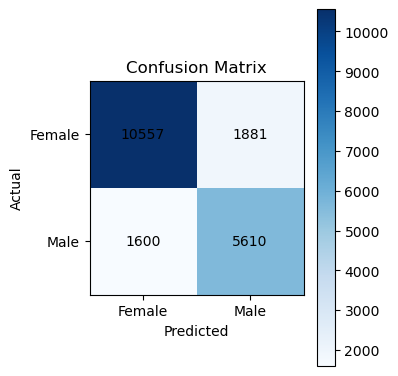

In [35]:
# --- Confusion matrix (best performing model) ---

best_preds = max(
    [(nb_acc, nb_preds, 'Naive Bayes'),
     (lr_acc, lr_preds, 'Logistic Regression'),
     (knn_acc, knn_preds, 'KNN')],
    key=lambda t: t[0]
)
cm = confusion_matrix(y_test, best_preds[1])

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0,1], ['Female','Male'])
plt.yticks([0,1], ['Female','Male'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

In [36]:
#Prediction Gender for a new name

def predict_gender(name, model, model_type='nb'):
    name = name.strip().lower()
    feats = extract_features(name)

    if model_type == 'nb':
        pred = model.predict_one(feats)
    else:
        vec = vectorize(feats).reshape(1, -1)
        pred = model.predict(vec)[0]

    return "Male" if pred == 1 else "Female"


test_names = ["hasan", "kakoli", "natasha", "sakib", "koli"]
print("--- Sample Predictions (Naive Bayes) ---")
for n in test_names:
    print(f"{n} -> {predict_gender(n, nb_model, 'nb')}")

--- Sample Predictions (Naive Bayes) ---
hasan -> Male
kakoli -> Female
natasha -> Female
sakib -> Male
koli -> Female
